# Lens Distortion Analysis
Compute and export pinhole-equivalent ray directions for each sensor pixel.

In [ ]:
import sys, os
import importlib
import numpy as np
import matplotlib.pyplot as plt
import OpenEXR, Imath

sys.path.insert(0, r"C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig")

# Force reload the module to pick up changes
if 'lens_simulation' in sys.modules:
    importlib.reload(sys.modules['lens_simulation'])

from lens_simulation import (
    setApertureTexturePath, createLensElements, computeLensSurfaceZ,
    addLensProfile, traceRayBackward, intersectSurfaceBackward, refract, n_air
)

# Configuration
APERTURE_SHAPE_PATH = r"C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\Assets\NoiseTextures\UniformStar\UniformStar.png"
setApertureTexturePath(APERTURE_SHAPE_PATH)

APERTURE_STOP_INDEX = 6
APERTURE_OPEN_THRESHOLD = 0.5
TEXTURED_APERTURE_INDEX = 5
SENSOR_WIDTH, SENSOR_HEIGHT = 36.0, 24.0  # mm (3:2 aspect)
SENSOR_PLANE_Z = 0.0
RAY_EXTENSION = 60.0

# Focus distance -> film offset
t_focus_distance = 45.0  # cm
SENSOR_PLANE_OFFSET = 237.480 / (t_focus_distance + -1.939) + 32.514

# Create lens
LENS_ELEMENTS = createLensElements(APERTURE_STOP_INDEX, SENSOR_PLANE_OFFSET)
LENS_SURFACE_Z = computeLensSurfaceZ(LENS_ELEMENTS)
APERTURE_Z = LENS_SURFACE_Z[TEXTURED_APERTURE_INDEX]

## Ray Tracing Functions

In [79]:
def traceRay(origin, target):
    """Trace ray from film through lens (backward direction)."""
    return traceRayBackward(origin, target, LENS_ELEMENTS, LENS_SURFACE_Z, APERTURE_OPEN_THRESHOLD)

def traceToAperture(origin, target):
    """Trace ray from film to aperture stop, return (miss_distance, hit_point)."""
    origin, direction = np.array(origin, dtype=float), np.array(target, dtype=float) - origin
    norm = np.linalg.norm(direction)
    if norm == 0: return np.inf, None
    direction /= norm
    
    n_current = n_air
    for idx in range(len(LENS_ELEMENTS) - 1, TEXTURED_APERTURE_INDEX - 1, -1):
        elem, z_surf = LENS_ELEMENTS[idx], LENS_SURFACE_Z[idx]
        result = intersectSurfaceBackward(origin, direction, elem.curvatureRadius, z_surf)
        if result is None: return np.inf, None
        hit, normal = result
        if idx == TEXTURED_APERTURE_INDEX:
            return np.linalg.norm(hit[:2]), hit
        n_target = LENS_ELEMENTS[idx - 1].n if idx > 0 else n_air
        refracted = refract(direction, normal, n_current / n_target) if n_target > 0 else None
        if refracted is None: return np.inf, None
        direction, origin, n_current = refracted / np.linalg.norm(refracted), hit, n_target
    return np.inf, None

def findApertureDirection(film_point, tol=1e-8, max_iters=1000):
    """Find direction from film point that hits aperture center via gradient descent."""
    film_point = np.array(film_point, dtype=float)
    target = np.array([0.0, 0.0, LENS_SURFACE_Z[-1]])
    step = 0.5 * LENS_ELEMENTS[-1].apertureRadius
    best_loss, _ = traceToAperture(film_point, target)
    
    diag = np.array([SENSOR_WIDTH, SENSOR_HEIGHT, 0.0])
    diag /= np.linalg.norm(diag[:2])
    step_dirs = [np.array([1,0,0]), np.array([-1,0,0]), np.array([0,1,0]), np.array([0,-1,0]), diag, -diag]
    
    for _ in range(max_iters):
        if best_loss <= tol and step <= tol: break
        improved = False
        for v in step_dirs:
            loss, _ = traceToAperture(film_point, target + step * v)
            if loss < best_loss:
                best_loss, target, improved = loss, target + step * v, True
        step *= 0.5
        if not improved and step <= tol: break
    
    d = target - film_point
    return d / np.linalg.norm(d) if np.linalg.norm(d) > 0 else None

## Sensor Grid Solver

In [80]:
def pixelToFilm(i, j, w, h):
    """Convert pixel coordinates to film position (mm)."""
    sx, sy = (2.0 * i + 1.0) / w - 1.0, (2.0 * j + 1.0) / h - 1.0
    return -sx * SENSOR_WIDTH * 0.5, -sy * SENSOR_HEIGHT * 0.5

def buildDiagonalLookup(numSamples=21, tol=1e-10, max_iters=32):
    """Build lookup table of directions along sensor diagonal."""
    radii, dirs = [], []
    for i in range(numSamples):
        t = i / (numSamples - 1) if numSamples > 1 else 0.0
        pt = np.array([t * 0.5 * SENSOR_WIDTH, t * 0.5 * SENSOR_HEIGHT, SENSOR_PLANE_Z])
        d = findApertureDirection(pt, tol=tol, max_iters=max_iters)
        if d is not None:
            radii.append(np.linalg.norm(pt[:2]))
            dirs.append(d)
    if not radii: return None
    order = np.argsort(radii)
    return {"radii": np.array(radii)[order], "dirs": np.array(dirs)[order], 
            "base_angle": np.arctan2(SENSOR_HEIGHT, SENSOR_WIDTH)}

def directionFromLookup(lookup, film_point):
    """Interpolate direction from lookup table with rotational symmetry."""
    if lookup is None: return None
    radii, dirs, base_angle = lookup["radii"], lookup["dirs"], lookup["base_angle"]
    r = np.linalg.norm(film_point[:2])
    d = np.array([np.interp(np.clip(r, radii[0], radii[-1]), radii, dirs[:, k]) for k in range(3)])
    d /= np.linalg.norm(d)
    if r > 0:
        rot = np.arctan2(film_point[1], film_point[0]) - base_angle
        c, s = np.cos(rot), np.sin(rot)
        d = np.array([c * d[0] - s * d[1], s * d[0] + c * d[1], d[2]])
        d /= np.linalg.norm(d)
    return d

def solveSensorGrid(width_px=90, height_px=60, diag_samples=21):
    """Compute aperture-targeting directions for entire sensor grid."""
    lookup = buildDiagonalLookup(diag_samples)
    directions = np.full((height_px, width_px, 3), np.nan)
    for j in range(height_px):
        for i in range(width_px):
            x, y = pixelToFilm(i, j, width_px, height_px)
            d = directionFromLookup(lookup, np.array([x, y, SENSOR_PLANE_Z]))
            if d is not None: directions[j, i] = d
    return directions

## Visualization

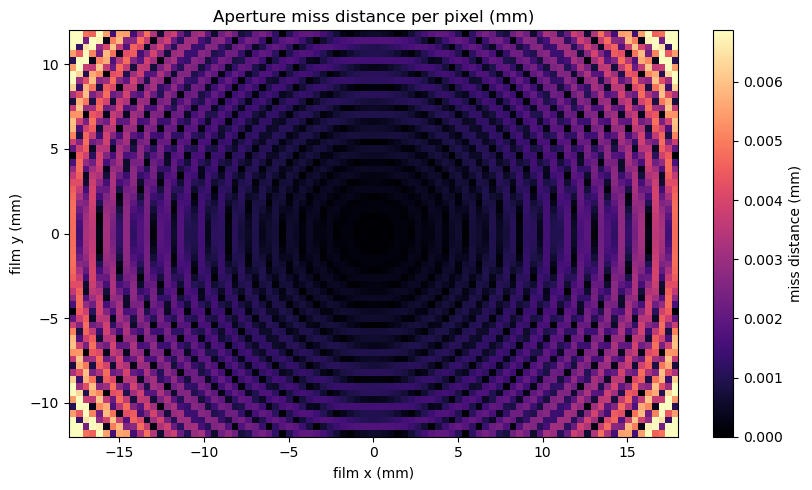

In [81]:
# Compute directions and loss map
dir_map = solveSensorGrid()
lookup = buildDiagonalLookup(21)
loss_map = np.full(dir_map.shape[:2], np.nan)

for j in range(dir_map.shape[0]):
    for i in range(dir_map.shape[1]):
        if np.isnan(dir_map[j, i]).any(): continue
        x, y = pixelToFilm(i, j, dir_map.shape[1], dir_map.shape[0])
        pt = np.array([x, y, SENSOR_PLANE_Z])
        loss_map[j, i], _ = traceToAperture(pt, pt + dir_map[j, i] * 100)

# Plot miss distance heatmap
fig, ax = plt.subplots(figsize=(9.5, 5.0))
extent = [-0.5 * SENSOR_WIDTH, 0.5 * SENSOR_WIDTH, -0.5 * SENSOR_HEIGHT, 0.5 * SENSOR_HEIGHT]
im = ax.imshow(loss_map, origin="lower", extent=extent, cmap="magma", vmin=0.0, vmax=np.nanpercentile(loss_map, 99))
ax.set(xlabel="film x (mm)", ylabel="film y (mm)", title="Aperture miss distance per pixel (mm)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="miss distance (mm)")
plt.tight_layout(); plt.show()

Plotted 345 rays


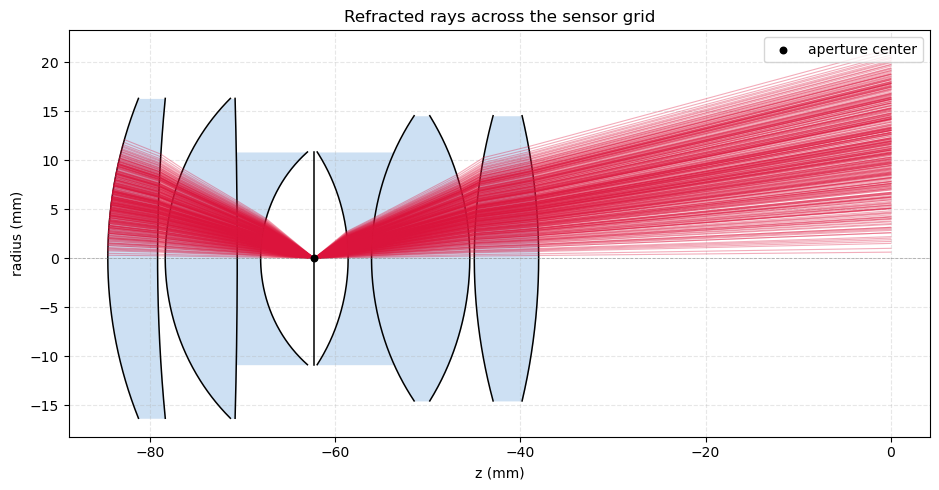

In [82]:
# Plot rays through lens
def plotGridRays(width_px=90, height_px=60, stride=4):
    directions = solveSensorGrid(width_px, height_px)
    travel = abs(LENS_SURFACE_Z[0]) + RAY_EXTENSION
    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    addLensProfile(ax, LENS_ELEMENTS)
    
    count = 0
    for j in range(0, height_px, stride):
        for i in range(0, width_px, stride):
            if np.isnan(directions[j, i]).any(): continue
            x, y = pixelToFilm(i, j, width_px, height_px)
            film_pt = np.array([x, y, SENSOR_PLANE_Z])
            result, path = traceRay(film_pt, film_pt + directions[j, i] * travel)
            if result:
                path = np.array(path)
                ax.plot(path[:, 2], np.linalg.norm(path[:, :2], axis=1), color="crimson", alpha=0.35, linewidth=0.8)
                count += 1
    
    ax.scatter([APERTURE_Z], [0], color="black", s=22, label="aperture center", zorder=5)
    ax.set(xlabel="z (mm)", ylabel="radius (mm)", title="Refracted rays across the sensor grid")
    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)
    ax.grid(True, linestyle="--", alpha=0.3); ax.legend(loc="upper right")
    plt.tight_layout(); print(f"Plotted {count} rays")
    return fig, ax

fig_grid, ax_grid = plotGridRays()

## Export to EXR

In [83]:
def writeExr(filepath, data):
    """Write single-channel EXR file."""
    h, w = data.shape
    header = OpenEXR.Header(w, h)
    header['channels'] = {'Y': Imath.Channel(Imath.PixelType(Imath.PixelType.FLOAT))}
    out = OpenEXR.OutputFile(filepath, header)
    out.writePixels({'Y': data.astype(np.float32).tobytes()})
    out.close()

def exportExitMaps(width_px=90, height_px=60, base_dir=r"C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\lens_distortion"):
    """Export ray exit positions and directions as EXR maps."""
    directions = solveSensorGrid(width_px, height_px)
    os.makedirs(base_dir, exist_ok=True)
    travel = abs(LENS_SURFACE_Z[0]) + RAY_EXTENSION
    
    pos = np.full((height_px, width_px, 3), np.nan, dtype=np.float32)
    dirs = np.full((height_px, width_px, 3), np.nan, dtype=np.float32)
    
    for j in range(height_px):
        for i in range(width_px):
            if np.isnan(directions[j, i]).any(): continue
            x, y = pixelToFilm(i, j, width_px, height_px)
            film_pt = np.array([x, y, SENSOR_PLANE_Z])
            result, path = traceRay(film_pt, film_pt + directions[j, i] * travel)
            if result and len(path) >= 2:
                pos[j, i], dirs[j, i] = path[1], result["direction"]
    
    for k, c in enumerate("xyz"):
        writeExr(os.path.join(base_dir, f"exit_position_{c}.exr"), pos[:, :, k])
        writeExr(os.path.join(base_dir, f"exit_direction_{c}.exr"), dirs[:, :, k])
    print(f"Saved EXRs to {base_dir}")
    return pos, dirs

pos_map, dir_map = exportExitMaps(90, 60)

Saved EXRs to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\lens_distortion
